In [3]:
import os
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from dotenv import load_dotenv

from langchain_community.document_loaders import DirectoryLoader, TextLoader
#from langchain.text_splitters import RecursiveCharacterTextSplitter
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate

In [5]:
load_dotenv()

PROJECT_ROOT = Path("..").resolve()
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "loan_approval_dataset.csv"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
KNOWLEDGE_BASE_DIR = PROJECT_ROOT / "knowledge_base"
CHROMA_DIR = ARTIFACTS_DIR / "chroma_db"

PREPROCESSOR_PATH = ARTIFACTS_DIR / "preprocessor.joblib"
MODEL_PATH = ARTIFACTS_DIR / "best_model.joblib"

print("DATA_PATH:", DATA_PATH)
print("PREPROCESSOR_PATH:", PREPROCESSOR_PATH)
print("MODEL_PATH:", MODEL_PATH)
print("KNOWLEDGE_BASE_DIR:", KNOWLEDGE_BASE_DIR)

DATA_PATH: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/data/raw/loan_approval_dataset.csv
PREPROCESSOR_PATH: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/artifacts/preprocessor.joblib
MODEL_PATH: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/artifacts/best_model.joblib
KNOWLEDGE_BASE_DIR: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/knowledge_base


In [6]:
df = pd.read_csv(DATA_PATH)

preprocessor = joblib.load(PREPROCESSOR_PATH)
model = joblib.load(MODEL_PATH)

print("Data shape:", df.shape)
print("Model loaded:", type(model).__name__)

Data shape: (4269, 13)
Model loaded: XGBClassifier


In [7]:
target_col = "loan_status"

df[target_col] = (
    df[target_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"approved": 1, "rejected": 0})
)

drop_cols = [col for col in ["loan_id", "Loan_ID"] if col in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")

# Clean categorical text columns for consistency
for col in ["education", "self_employed"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

X = df.drop(columns=[target_col])
y = df[target_col]

print(X.head())

   no_of_dependents     education self_employed  income_annum  loan_amount  \
0                 2      Graduate            No       9600000     29900000   
1                 0  Not Graduate           Yes       4100000     12200000   
2                 3      Graduate            No       9100000     29700000   
3                 3      Graduate            No       8200000     30700000   
4                 5  Not Graduate           Yes       9800000     24200000   

   loan_term  cibil_score  residential_assets_value  commercial_assets_value  \
0         12          778                   2400000                 17600000   
1          8          417                   2700000                  2200000   
2         20          506                   7100000                  4500000   
3          8          467                  18200000                  3300000   
4         20          382                  12400000                  8200000   

   luxury_assets_value  bank_asset_value  
0      

In [8]:
X_processed = preprocessor.transform(X)
feature_names = preprocessor.get_feature_names_out()

X_processed_df = pd.DataFrame(
    X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed,
    columns=feature_names,
    index=X.index
)

print("Processed shape:", X_processed_df.shape)
print("Feature names:", feature_names)

Processed shape: (4269, 13)
Feature names: ['num__no_of_dependents' 'num__income_annum' 'num__loan_amount'
 'num__loan_term' 'num__cibil_score' 'num__residential_assets_value'
 'num__commercial_assets_value' 'num__luxury_assets_value'
 'num__bank_asset_value' 'cat__education_ Graduate'
 'cat__education_ Not Graduate' 'cat__self_employed_ No'
 'cat__self_employed_ Yes']


In [9]:
row_idx = 0

input_data = X.loc[row_idx].to_dict()
actual_label = y.loc[row_idx]

print("Input row:")
print(json.dumps(input_data, indent=2, default=str))
print("Actual label:", actual_label)

Input row:
{
  "no_of_dependents": 2,
  "education": "Graduate",
  "self_employed": "No",
  "income_annum": 9600000,
  "loan_amount": 29900000,
  "loan_term": 12,
  "cibil_score": 778,
  "residential_assets_value": 2400000,
  "commercial_assets_value": 17600000,
  "luxury_assets_value": 22700000,
  "bank_asset_value": 8000000
}
Actual label: 1


In [10]:
X_row_processed = X_processed_df.loc[[row_idx]]

pred_prob = model.predict_proba(X_row_processed)[:, 1][0]
pred_label = "Approved" if pred_prob >= 0.5 else "Rejected"

prediction_result = {
    "prediction": pred_label,
    "probability": float(pred_prob)
}

print(prediction_result)

{'prediction': 'Approved', 'probability': 0.9994674324989319}


In [11]:
booster = model.get_booster()

dmat = xgb.DMatrix(
    X_processed_df,
    feature_names=X_processed_df.columns.tolist()
)

contribs = booster.predict(dmat, pred_contribs=True)

contrib_df = pd.DataFrame(
    contribs,
    columns=X_processed_df.columns.tolist() + ["bias"],
    index=X_processed_df.index
)

contrib_df.head()

,num__no_of_dependents,num__income_annum,num__loan_amount,num__loan_term,num__cibil_score,num__residential_assets_value,num__commercial_assets_value,num__luxury_assets_value,num__bank_asset_value,cat__education_ Graduate,cat__education_ Not Graduate,cat__self_employed_ No,cat__self_employed_ Yes,bias
0,-0.045436,-0.975458,1.158663,-1.388918,6.927210,0.722219,0.468505,-0.042614,0.178157,0.048734,-0.004506,0.031798,-0.008943,0.467932
1,0.113179,-0.042352,-0.426075,-2.906915,-4.357171,0.518304,0.211294,0.016605,0.075735,0.085375,-0.012010,-0.041761,-0.008307,0.467932
2,0.084856,-1.171643,1.976972,-3.478676,-4.281487,0.450409,0.306784,-0.152576,0.097334,0.046529,-0.003683,0.035686,-0.012018,0.467932
3,0.114877,-0.979829,2.293959,-3.292697,-4.179553,-0.055070,0.314002,-0.241788,0.063577,0.019838,-0.003814,0.025790,-0.007527,0.467932
4,-0.155613,-1.378596,0.796717,-2.582560,-4.535844,0.104890,0.016245,-0.157702,0.098234,0.040781,-0.006851,0.041038,-0.012018,0.467932


In [12]:
def extract_local_reason_summary(contrib_df, row_idx, top_n=5):
    row_contrib = contrib_df.loc[row_idx].drop("bias").sort_values()

    top_negative = row_contrib.head(top_n)
    top_positive = row_contrib.tail(top_n).sort_values(ascending=False)

    return {
        "top_positive": {k: float(v) for k, v in top_positive.to_dict().items()},
        "top_negative": {k: float(v) for k, v in top_negative.to_dict().items()}
    }

local_explanation = extract_local_reason_summary(contrib_df, row_idx=row_idx, top_n=5)
print(json.dumps(local_explanation, indent=2))

{
  "top_positive": {
    "num__cibil_score": 6.927209854125977,
    "num__loan_amount": 1.158663272857666,
    "num__residential_assets_value": 0.7222190499305725,
    "num__commercial_assets_value": 0.46850499510765076,
    "num__bank_asset_value": 0.1781574785709381
  },
  "top_negative": {
    "num__loan_term": -1.3889175653457642,
    "num__income_annum": -0.9754577875137329,
    "num__no_of_dependents": -0.04543555527925491,
    "num__luxury_assets_value": -0.04261438548564911,
    "cat__self_employed_ Yes": -0.008942937478423119
  }
}


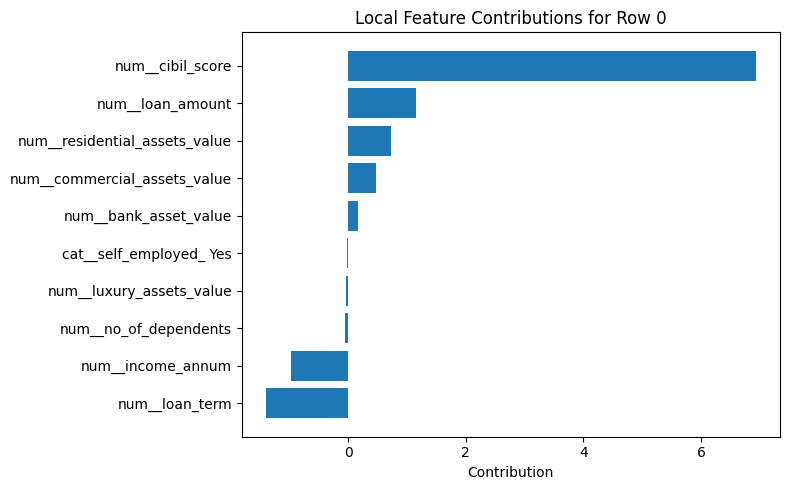

In [13]:
import matplotlib.pyplot as plt

row_contrib = contrib_df.loc[row_idx].drop("bias").sort_values()
top_negative = row_contrib.head(5)
top_positive = row_contrib.tail(5)

local_plot_df = pd.concat([top_negative, top_positive]).sort_values()

plt.figure(figsize=(8, 5))
plt.barh(local_plot_df.index, local_plot_df.values)
plt.title(f"Local Feature Contributions for Row {row_idx}")
plt.xlabel("Contribution")
plt.tight_layout()
plt.show()

In [14]:
loader = DirectoryLoader(
    str(KNOWLEDGE_BASE_DIR),
    glob="**/*.md",
    loader_cls=TextLoader
)

docs = loader.load()

print("Loaded docs:", len(docs))
for doc in docs:
    print(doc.metadata.get("source"))

Loaded docs: 4
/Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/knowledge_base/improvement_tips.md
/Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/knowledge_base/faq.md
/Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/knowledge_base/feature_meaning.md
/Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/knowledge_base/approval_rules.md


In [15]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

split_docs = text_splitter.split_documents(docs)
print("Chunks:", len(split_docs))

Chunks: 14


In [16]:
embeddings = OpenAIEmbeddings()

vectorstore = Chroma.from_documents(
    documents=split_docs,
    embedding=embeddings,
    persist_directory=str(CHROMA_DIR)
)

retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print("Retriever ready.")

Retriever ready.


In [17]:
def retrieve_docs(retriever, query: str):
    if hasattr(retriever, "invoke"):
        return retriever.invoke(query)
    elif hasattr(retriever, "get_relevant_documents"):
        return retriever.get_relevant_documents(query)
    else:
        raise AttributeError("Retriever has neither 'invoke' nor 'get_relevant_documents'.")

In [18]:
def format_dict_pretty(data):
    return json.dumps(data, indent=2, default=str)

def format_retrieved_context(retrieved_docs):
    parts = []
    for i, doc in enumerate(retrieved_docs, start=1):
        source = os.path.basename(doc.metadata.get("source", "unknown"))
        content = doc.page_content.strip()
        parts.append(f"[Document {i}: {source}]\n{content}")
    return "\n\n".join(parts)

In [19]:
prompt = ChatPromptTemplate.from_template("""
You are a loan approval assistant.

Use the following information:
1. Applicant input data
2. Model prediction result
3. Local explanation from the model
4. Retrieved knowledge base context

Applicant input data:
{input_data}

Prediction result:
{prediction_result}

Local explanation:
{local_explanation}

Retrieved rule context:
{retrieved_context}

User question:
{question}

Instructions:
- Use the applicant input values when relevant.
- Clearly mention the final model decision.
- Use the local explanation to describe what pushed the decision toward approval or rejection.
- Use the retrieved context as grounding.
- Do not invent unsupported reasons.
- Be practical and human-readable.
- For summaries, write in a concise analyst-friendly style.
""")

In [20]:
llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

print("LLM ready.")

LLM ready.


In [21]:
def answer_loan_question(
    question: str,
    input_data: dict,
    prediction_result: dict,
    local_explanation: dict,
    retriever,
    llm,
    top_k: int = 3
):
    retrieved_docs = retrieve_docs(retriever, question)
    retrieved_context = format_retrieved_context(retrieved_docs)

    messages = prompt.format_messages(
        input_data=format_dict_pretty(input_data),
        prediction_result=format_dict_pretty(prediction_result),
        local_explanation=format_dict_pretty(local_explanation),
        retrieved_context=retrieved_context,
        question=question
    )

    response = llm.invoke(messages)

    return {
        "question": question,
        "answer": response.content,
        "retrieved_docs": [
            {
                "source": doc.metadata.get("source"),
                "content": doc.page_content
            }
            for doc in retrieved_docs[:top_k]
        ]
    }

In [22]:
summary_question = "Summarize this loan application for an analyst."

summary_result = answer_loan_question(
    question=summary_question,
    input_data=input_data,
    prediction_result=prediction_result,
    local_explanation=local_explanation,
    retriever=retriever,
    llm=llm
)

print(summary_result["answer"])

The applicant, a graduate with 2 dependents and not self-employed, has an annual income of ₹9,600,000. They requested a loan amount of ₹29,900,000 with a short loan term of 12 months. Their credit score is strong at 778. Asset values include residential assets worth ₹2,400,000, commercial assets ₹17,600,000, luxury assets ₹22,700,000, and bank assets ₹8,000,000.

The model strongly approved the loan with a high confidence probability of 99.95%. Key positive factors driving approval were the excellent credit score (largest positive influence), the high loan amount requested, and substantial residential, commercial, and bank asset values. Negative influences included the very short loan term, relatively lower income compared to the loan amount, number of dependents, and luxury asset value, but these were outweighed by the positives.

In line with typical approval criteria, the applicant demonstrates strong creditworthiness and a solid financial profile supported by significant assets. Th

In [23]:
questions = [
    "Why was this application approved or rejected?",
    "What factors helped this application most?",
    "What factors weakened this application?",
    "What should improve before reapplying?",
    "Does credit score matter a lot in this case?",
    "Summarize this loan application for an analyst."
]

for q in questions:
    result = answer_loan_question(
        question=q,
        input_data=input_data,
        prediction_result=prediction_result,
        local_explanation=local_explanation,
        retriever=retriever,
        llm=llm
    )

    print("\n" + "=" * 100)
    print("QUESTION:", result["question"])
    print("-" * 100)
    print(result["answer"])


QUESTION: Why was this application approved or rejected?
----------------------------------------------------------------------------------------------------
The loan application was **approved** with a very high confidence (probability ~99.95%).

Key factors driving this approval include:

- **High CIBIL score (778):** This was the strongest positive influence, indicating excellent creditworthiness.
- **Large loan amount requested (29,900,000):** Surprisingly, this had a positive contribution, likely reflecting the model's recognition of the applicant's capacity to handle a large loan given their financial profile.
- **Significant asset values:** Residential (2,400,000), commercial (17,600,000), and bank assets (8,000,000) all positively supported the decision, demonstrating strong financial backing.

Negative influences were present but outweighed by positives:

- **Short loan term (12 months):** This negatively impacted the decision, as shorter terms can increase repayment pressure

In [24]:
final_output = {
    "row_idx": row_idx,
    "input_data": input_data,
    "prediction_result": prediction_result,
    "local_explanation": local_explanation,
    "agent_summary": summary_result["answer"],
    "retrieved_docs": summary_result["retrieved_docs"]
}

output_path = ARTIFACTS_DIR / "phase5_final_inference_and_agent_output.json"

with open(output_path, "w") as f:
    json.dump(final_output, f, indent=2, default=str)

print("Saved final output to:", output_path)

Saved final output to: /Users/pranavsrinivasvenkatesh/Projects/ML with Agentic AI/artifacts/phase5_final_inference_and_agent_output.json
